# Edge handling experiments

A deconvolution treats the image as the whole world. It is not: the object
carries on past the edge of the stack, and light from outside it fell on the
detector. Assume the image wraps around instead -- which is what an FFT-based
convolution does unless told otherwise -- and the estimate grows artifacts at
the boundary. This notebook is about seeing that happen, and about what proper
edge handling does to it.

For background on the derivation of the Richardson-Lucy equation for
non-circulant boundaries see [this application
note](http://bigwww.epfl.ch/deconvolution/challenge2013/index.html?p=doc_math_rl).

When the image is extended we can think of it as extending our *solution
space*. The acquired image has then been multiplied by a window $w$ in the
larger space, and the RL equation becomes

$$
    o_{k+1} = \frac{o_{k}\left[\frac{wi}{o_{k}*h}*h^*\right]}{n}
$$

where $n$ is a normalization factor calculated as `HTones`. The $H$ operator on
the image is convolution followed by multiplication by a window

$$
measuredimage=w(h*reality)
$$

so `HTones` is the window applied to the `ones` matrix, followed by convolution
with the conjugate of the PSF

$$
(w(ones))*h^*
$$

In skop this is the `noncirc` flag on
`skop.ops.deconvolve.richardson_lucy:richardson_lucy`. It pads the image out
rather than letting it wrap, which costs eight times the voxels on a 3-D stack.

## Setup

```sh
pip install scikit-ops tifffile matplotlib "tnia-python[plotting]"
```

`tifffile` reads the stack and `tnia-python` draws the projection figures. The
ops need nothing installed here: skop builds the environment each one declares
the first time it runs, so the first deconvolution pauses while `skimage` is
built and the first PSF while `sdeconv` is, and after that they are warm and
shared.

This is the part that has changed most since the original notebook, which asked
for one conda environment carrying clij2fft, devbio-napari, sdeconv and
tnia-python together, pinned to Python 3.9. Only tnia-python survives, and only
for its plotting — the deconvolution itself was migrated into ops.

## Load the test image

A 2.5 µm bead, imaged on a 1.4 NA oil objective. The original is from the
[EPFL bead dataset](http://bigwww.epfl.ch/deconvolution/bead/); the copy in
`test_images/deconvolution/bead-2.5um.tif` is cropped, both to keep the
repository small and to put the bead near enough to an edge that the edge
handling has something to show.

The z axis is reversed on load, so that positive depth runs *below* the
coverslip -- the convention the PSF ops expect when asked for a PSF computed at
depth.

In [1]:
from pathlib import Path

import tifffile

# The notebook may be launched from anywhere in the checkout, so find the
# images by walking up rather than by counting '..' segments.
root = Path.cwd()
while not (root / "test_images").is_dir():
    if root == root.parent:
        raise SystemExit("Run this from inside the scikit-ops checkout.")
    root = root.parent

bead = tifffile.imread(root / "test_images" / "deconvolution" / "bead-2.5um.tif")
bead = bead[::-1, :, :]

xy_spacing = 0.0645  # µm
z_spacing = 0.16  # µm
ratio = z_spacing / xy_spacing

z_to_view = bead.shape[0] // 2

print(f"{bead.shape} {bead.dtype}, range {bead.min()}-{bead.max()}")
print(f"voxel {xy_spacing} x {xy_spacing} x {z_spacing} µm, z:xy ratio {ratio:.2f}")

(50, 256, 256) uint16, range 199-3743
voxel 0.0645 x 0.0645 x 0.16 µm, z:xy ratio 2.48


## Look at it

`show_xy_zy_slice` puts an xy slice beside a zy slice and stretches z by
`sz=ratio`, so anisotropic voxels come out square. Worth the import: the
artifacts this notebook is about live in zy and are invisible in xy.

This is a host dependency, not an op. Projections return a figure rather than
an array, which no role covers, and they are display rather than computation —
so tnia-python sits in the notebook's environment and no op imports it. The
deconvolution went the other way and was migrated into ops. If that reverses
later — several backends worth wrapping rather than porting — this import
stays and an op-level one joins it.

Text(0.5, 0.98, 'bead, xy and zy')

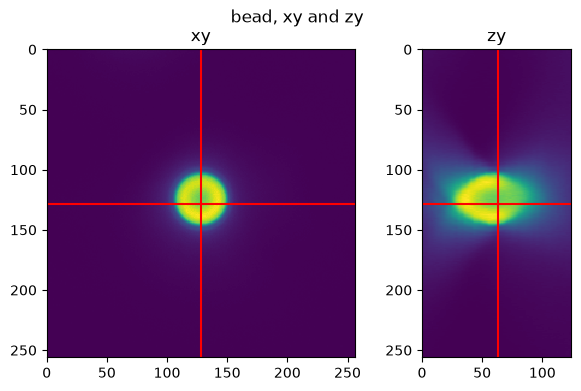

In [2]:
from tnia.plotting.projections import show_xy_zy_slice

fig = show_xy_zy_slice(bead, 128, 128, z_to_view, sz=ratio, figsize=(7, 4))
fig.suptitle("bead, xy and zy")

## The PSF

The original computed this with `gibson_lanni_3D` and then recentred it with
`recenter_psf_axial` — 599 planes computed to keep 255, because sdeconv puts
the peak where the physics puts it rather than on the middle plane, and a
deconvolution kernel wants it centred. `skop.ops.kernels.gibson_lanni` does
both: it works out how much axial headroom the depth needs, computes that, and
crops back to the `z_size` asked for.

The refractive index of the medium the bead is embedded in is not in the
metadata. It is close to, but not the same as, the immersion oil; an earlier
experiment put it at about 1.49, which is what `ns` is here.

Depth matters more than either. `pz` is what makes the PSF axially asymmetric,
and this bead sat around 20 µm below the coverslip — the middle of the original
256-plane stack that this 50-plane crop was taken from. Depth is a property of
the specimen, not of the crop, so it does not shrink with it.

This is the first op the notebook runs, so it pauses here the first time while
skop builds the `sdeconv` environment.

In [3]:
import skop
from skop.ops.kernels import gibson_lanni

runner = skop.Runner()


def show_progress(event):
    if event.message:
        print(f"  {event.message}", end="\r")


depth = 128 * z_spacing  # µm below the coverslip

psf = runner.run(
    gibson_lanni,
    xy_size=bead.shape[2],
    z_size=bead.shape[0],
    voxel_size_xy=xy_spacing,
    voxel_size_z=z_spacing,
    numerical_aperture=1.4,
    ni=1.518,
    ns=1.49,
    pz=depth,
    wavelength=0.53,
    on_progress=show_progress,
)

print(f"\npsf {psf.shape} {psf.dtype}, sums to {psf.sum():.6f}")

  Recentringa 459x256x256 Gibson-Lanni PSF
psf (50, 256, 256) float32, sums to 1.000000


Text(0.5, 0.98, 'Gibson-Lanni psf, xy and zy maxima')

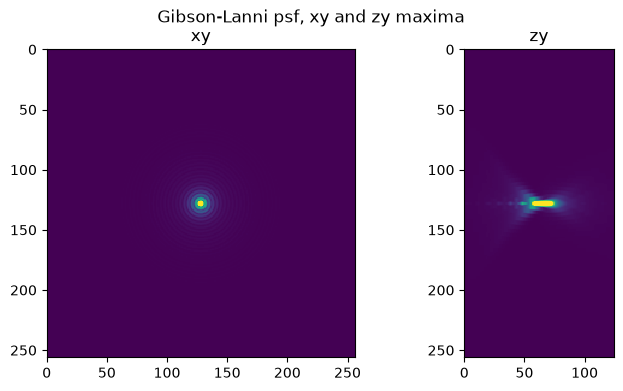

In [4]:
from tnia.plotting.projections import show_xy_zy_max

# vmax well below the peak, or the flare that the whole notebook is about is
# invisible next to it.
fig = show_xy_zy_max(psf, sz=ratio, vmax=psf.max() / 4, figsize=(8, 4))
fig.suptitle("Gibson-Lanni psf, xy and zy maxima")

## Deconvolve the centred bead

2.5 µm of bead in 8 µm of stack, under a PSF whose flare is longer than either:
light from the bead reaches the top and bottom planes, so the z edges cut
through signal even though the object itself is nowhere near them. Circulant
handling wraps that signal around to the other end of the stack, and the
iteration then has to explain light that arrives from the wrong direction.

`richardson_lucy_cupy` runs the iteration on an NVIDIA GPU. `richardson_lucy`
is the same algorithm on the CPU and gives the same answer to about five
decimal places, but non-circulant handling extends this stack to 100×512×512 —
eight times the voxels — and 1200 CPU iterations of that is a long wait.

The original ran clij2fft here, with a regularization factor of 2e-5. These ops
carry no regularization term; on data this clean it is not missed.

In [5]:
from skop.ops.deconvolve import richardson_lucy_cupy

ITERATIONS = 1200

circulant = runner.run(
    richardson_lucy_cupy,
    image=bead,
    psf=psf,
    num_iters=ITERATIONS,
    noncirc=False,
    on_progress=show_progress,
)

noncirculant = runner.run(
    richardson_lucy_cupy,
    image=bead,
    psf=psf,
    num_iters=ITERATIONS,
    noncirc=True,
    on_progress=show_progress,
)

print(f"\ncirculant {circulant.shape} {circulant.dtype}")
print(f"non-circulant {noncirculant.shape} {noncirculant.dtype}")

  Deconvolution complete
circulant (50, 256, 256) float32
non-circulant (50, 256, 256) float32


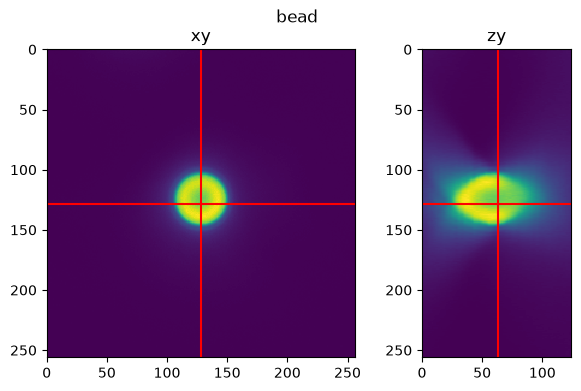

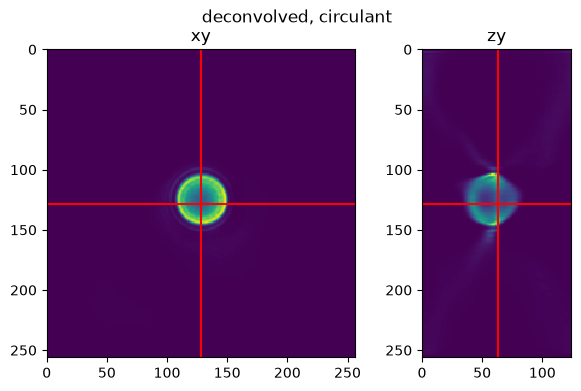

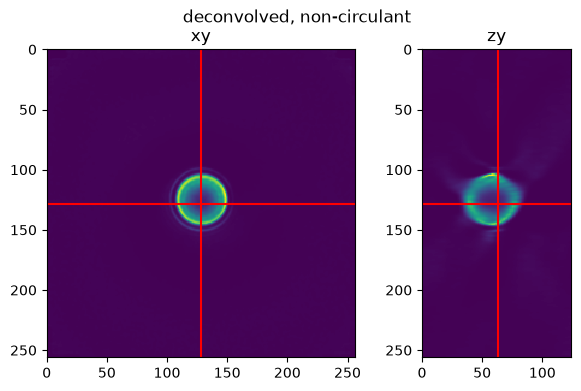

In [6]:
for title, volume in (
    ("bead", bead),
    ("deconvolved, circulant", circulant),
    ("deconvolved, non-circulant", noncirculant),
):
    fig = show_xy_zy_slice(volume, 128, 128, z_to_view, sz=ratio, figsize=(7, 4))
    fig.suptitle(title)

## The same again, on half a bead

Cut the stack in two and the bead is sliced through its equator, so the object
*is* the boundary — the case the whole argument is about. Half of the light
that formed the bottom half of that bead was recorded; none of the light from
the half that is now missing was.

The PSF is recomputed rather than cropped. `gibson_lanni` recentres what it
returns, so asking for 25 planes puts the peak on plane 12; slicing the
50-plane PSF down the middle by hand would leave it half a plane off.


half bead (25, 256, 256), psf (25, 256, 256)


Text(0.5, 0.98, 'half bead')

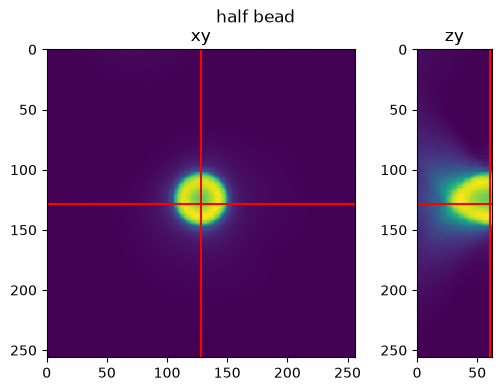

In [7]:
half_bead = bead[: bead.shape[0] // 2]
half_z_to_view = half_bead.shape[0] - 1  # the cut plane

psf_half = runner.run(
    gibson_lanni,
    xy_size=half_bead.shape[2],
    z_size=half_bead.shape[0],
    voxel_size_xy=xy_spacing,
    voxel_size_z=z_spacing,
    numerical_aperture=1.4,
    ni=1.518,
    ns=1.49,
    pz=depth,
    wavelength=0.53,
    on_progress=show_progress,
)

print(f"\nhalf bead {half_bead.shape}, psf {psf_half.shape}")

fig = show_xy_zy_slice(half_bead, 128, 128, half_z_to_view, sz=ratio, figsize=(6, 4))
fig.suptitle("half bead")

In [8]:
half_circulant = runner.run(
    richardson_lucy_cupy,
    image=half_bead,
    psf=psf_half,
    num_iters=ITERATIONS,
    noncirc=False,
    on_progress=show_progress,
)

half_noncirculant = runner.run(
    richardson_lucy_cupy,
    image=half_bead,
    psf=psf_half,
    num_iters=ITERATIONS,
    noncirc=True,
    on_progress=show_progress,
)

runner.close()
print("\ndone")


done


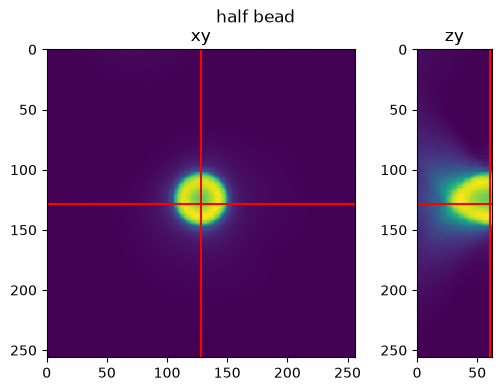

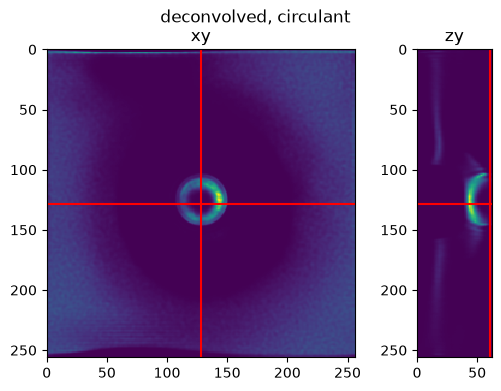

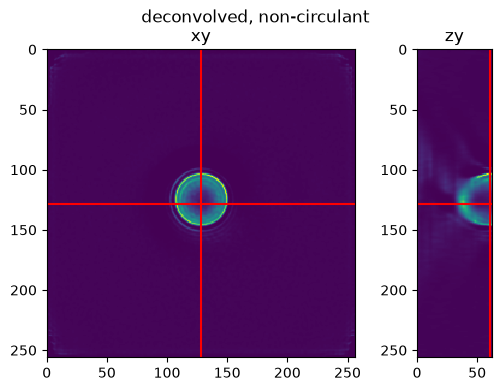

In [9]:
for title, volume in (
    ("half bead", half_bead),
    ("deconvolved, circulant", half_circulant),
    ("deconvolved, non-circulant", half_noncirculant),
):
    fig = show_xy_zy_slice(volume, 128, 128, half_z_to_view, sz=ratio, figsize=(6, 4))
    fig.suptitle(title)

## What to take from it

Edge handling is not a finishing touch. The centred bead has nothing at its
boundary and still comes out wrong when the deconvolution is allowed to assume
the stack wraps; the half bead, where the object runs off the edge, is worse.
Non-circulant handling costs eight times the voxels on a 3-D stack, and buys a
result that is not lying about what was outside the field of view.

Everything above is `noncirc=True` versus `noncirc=False` on one op. The
argument for the flag is the pair of figures, not the flag.